<a href="https://colab.research.google.com/github/melody12-cpu/Credit-Card-Fraud-Detection-/blob/main/fraudtransactions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fraud Detection Machine Learning Project

In [3]:
import pandas as pd
from google.colab import files
import io

#Interactive Data Loading
print("Please upload your transaction data CSV file.")
uploaded = files.upload()

if uploaded:
    for fn in uploaded.keys():
        print('User uploaded file "{name}" with length {length} bytes'.format(name=fn, length=len(uploaded[fn])))
        # Read the uploaded CSV file into a pandas DataFrame
        df = pd.read_csv(io.BytesIO(uploaded[fn]))
        print("Data loaded successfully.")
        display(df.head())
        break # Assuming only one file will be uploaded for now
else:
    print("No file uploaded. DataFrame remains empty.")
    df = pd.DataFrame() # Ensure df is defined even if no file is uploaded


Please upload your transaction data CSV file.


Saving creditcard.csv to creditcard.csv
User uploaded file "creditcard.csv" with length 150828752 bytes
Data loaded successfully.


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

if not df.empty:
    # Define target and features
    if 'Class' in df.columns:
        X = df.drop('Class', axis=1)
        y = df['Class']

        # Identify categorical and numerical features
        categorical_features = X.select_dtypes(include=['object', 'category']).columns
        numerical_features = X.select_dtypes(include=['int64', 'float64']).columns

        # Create preprocessing pipelines for numerical and categorical features
        numerical_transformer = StandardScaler()
        categorical_transformer = OneHotEncoder(handle_unknown='ignore')

        # Create a preprocessor using ColumnTransformer
        preprocessor = ColumnTransformer(
            transformers=[
                ('num', numerical_transformer, numerical_features),
                ('cat', categorical_transformer, categorical_features)
            ])

        # Split data into training and testing sets
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

        print("Data preprocessing setup complete. Ready for model training.")
        print(f"Training set size: {X_train.shape[0]} samples")
        print(f"Test set size: {X_test.shape[0]} samples")
    else:
        print("Error: 'Class' column not found. Please ensure your target variable is named 'Class' or adjust the code.")
else:
    print("Skipping preprocessing as the DataFrame is empty.")


Data preprocessing setup complete. Ready for model training.
Training set size: 227845 samples
Test set size: 56962 samples


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

if 'X_train' in locals() and not df.empty:
    # Create a pipeline that combines preprocessing and a classifier
    model_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                   ('classifier', LogisticRegression(solver='liblinear', random_state=42, class_weight={0: 1, 1: 50}))]) # 'class_weight' helps with imbalanced data

    # Train the model
    model_pipeline.fit(X_train, y_train)

    print("Model training complete.")

    # Make predictions on the test set
    y_pred = model_pipeline.predict(X_test)
    y_proba = model_pipeline.predict_proba(X_test)[:, 1]

    # Evaluate the model
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nROC AUC Score:")
    print(roc_auc_score(y_test, y_proba))
else:
    print("Skipping model training as data is not prepared or DataFrame is empty.")

Model training complete.

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.45      0.89      0.59        98

    accuracy                           1.00     56962
   macro avg       0.72      0.94      0.80     56962
weighted avg       1.00      1.00      1.00     56962


Confusion Matrix:
[[56756   108]
 [   11    87]]

ROC AUC Score:
0.9693262047362559


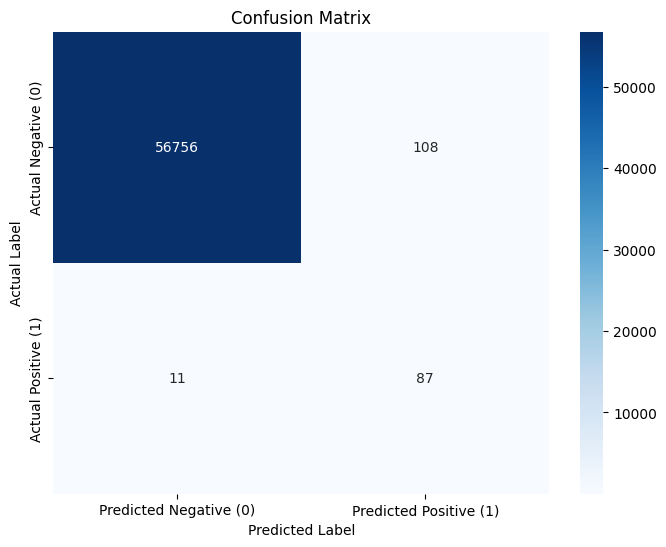

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

# Plotting Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Negative (0)', 'Predicted Positive (1)'],
            yticklabels=['Actual Negative (0)', 'Actual Positive (1)'])
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()


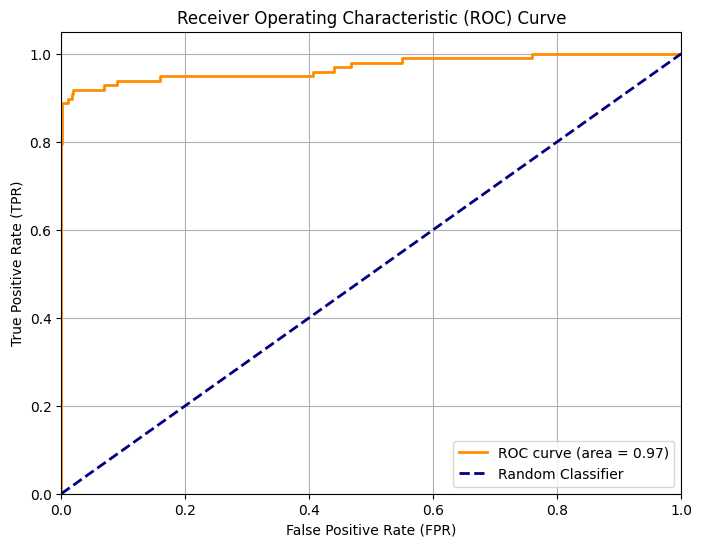

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

#Plotting ROC Curve

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [8]:
import numpy as np

if 'model_pipeline' in locals() and not df.empty:
    #Placeholder for New Transaction Data
    new_transaction_data = pd.DataFrame({
        'Time': [0.0], # Example: Time elapsed since first transaction
        'V1': [0.0], 'V2': [0.0], 'V3': [0.0], 'V4': [0.0], 'V5': [0.0],
        'V6': [0.0], 'V7': [0.0], 'V8': [0.0], 'V9': [0.0], 'V10': [0.0],
        'V11': [0.0], 'V12': [0.0], 'V13': [0.0], 'V14': [0.0], 'V15': [0.0],
        'V16': [0.0], 'V17': [0.0], 'V18': [0.0], 'V19': [0.0], 'V20': [0.0],
        'V21': [0.0], 'V22': [0.0], 'V23': [0.0], 'V24': [0.0], 'V25': [0.0],
        'V26': [0.0], 'V27': [0.0], 'V28': [0.0],
        'Amount': [0.0] # Example: Transaction amount
    })

    # Predict if the new transaction is fraud
    new_prediction = model_pipeline.predict(new_transaction_data)
    new_prediction_proba = model_pipeline.predict_proba(new_transaction_data)[:, 1]

    print(f"\nPrediction for new transaction: {'Fraudulent' if new_prediction[0] == 1 else 'Not Fraudulent'}")
    print(f"Probability of fraud: {new_prediction_proba[0]:.4f}")
else:
    print("Skipping prediction for new information as the model was not trained or DataFrame is empty.")


Prediction for new transaction: Not Fraudulent
Probability of fraud: 0.0053
